## Question 1 (Camera Projection)

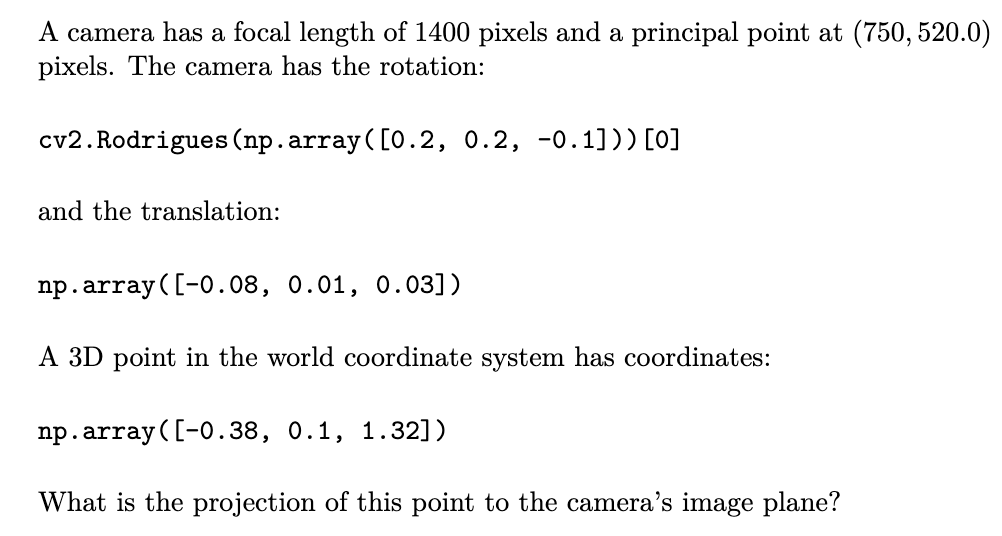

In [3]:
import numpy as np
import cv2

FocalLength = 1400 
PrincipalPoint = (750, 520.0)

# Camera rotation
R = cv2.Rodrigues(np.array([0.2, 0.2, -0.1]))[0]
# Camera translation
t = np.array([-0.08, 0.01, 0.03])
#3D point in world coordinates
P_world = np.array([-0.38, 0.1, 1.32])

# What is the projection of this point to the cameras image plane? 

# 1) First move is to define Intrinsic Camera Matrix (K) 
K = np.array([[FocalLength, 0, PrincipalPoint[0]], 
              [0, FocalLength, PrincipalPoint[1]], 
              [0, 0, 1]])

#Just another way to see how to insert the values in the matrix
K1 = np.array([[1400, 0, 750], 
              [0, 1400, 520], 
              [0, 0, 1]])

# 2) Transform to Camera Space with formula: P_camera = R * P_world + t
P_camera = R @ P_world + t
print("P_camera: ", P_camera)

# 3) Project to image plane with formula: p_image = K * P_camera
p_image = K @ P_camera
print("p_image: ", p_image)

P_camera:  [-0.19177883 -0.135751    1.39494034]
p_image:  [777.71489132 535.31758426   1.39494034]


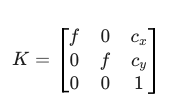

In [4]:
# 4) Final step = Normalize the coordinates by dividing by the last element
p_image_normalized = p_image / p_image[2]
print("p_image_normalized: ", p_image_normalized)

p_image_normalized:  [557.52555675 383.75661509   1.        ]


## Question 2 (Homography Estimation)


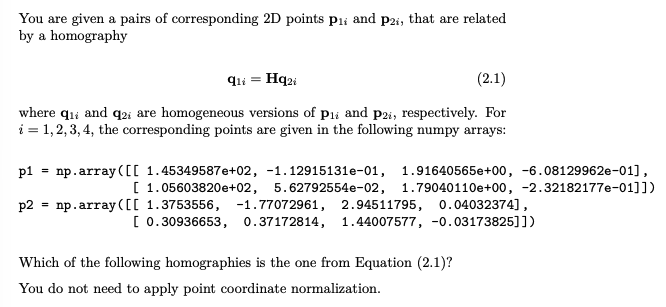

In [13]:
## To understand this exercise: 
# Homography matrix has 8 degrees of freedom, so we need 4 points to solve for it. (9th element is scale factor)
# i = 1, 2, 3, 4 (exactly 4 points)

# Use the full scientific notation values from the prompt
p1 = np.array([
    [1.45349587e+02, -1.12915131e-01, 1.91640565e+00, -6.08129962e-01],
    [1.05603820e+02, 5.62792554e-02, 1.79040110e+00, -2.32182177e-01]
]).T

p2 = np.array([
    [1.3753556, -1.77072961, 2.94511795, 0.04032374],
    [0.30936653, 0.37172814, 1.44007577, -0.03173825]
]).T

## Look at the Homography equation 2.1: (p1 = H * p2)
# 1 ) Calculate homography matrix
H = cv2.findHomography(p2, p1)[0]
print("Homography Matrix H: ", H)

Homography Matrix H:  [[-0.21161806 -0.25066191 -0.57876429]
 [-0.27191854 -0.30516881 -0.21991175]
 [-0.83009535  0.43688786  1.        ]]


Source points (srcPoints): p2, 
Destination points (dstPoints): p1
​

In [ ]:
# Scale so H[0,0] = 1.0
H_scaled = H / H[0, 0]
print(H_scaled)

[[ 1.          1.18450151  2.73494755]
 [ 1.28494962  1.44207355  1.03919177]
 [ 3.92261111 -2.06451125 -4.72549463]]


## Question 3 (Fundamental Matrix Estimation)

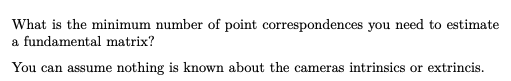

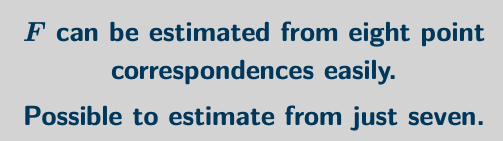

The minimum number of point correspondences needed is 7 (using the non-linear 7-point algorithm) or 8 (using the standard linear 8-point algorithm).

Fundamental Matrix (F): Relates pixel coordinates between two uncalibrated cameras. It has 7 degrees of freedom.

Why 7? The matrix is 3×3 (9 elements), but it is defined up to a scale (minus 1) and must satisfy the constraint det(F)=0 (minus another 1).

## Question 4 (Radial Lens Distortion)

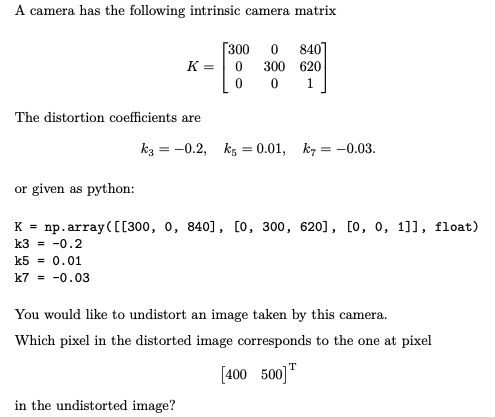

In [17]:

K4 = np.array([[300, 0, 840], 
              [0, 300, 620], 
              [0, 0, 1]], dtype=float)

# Distortion coefficients
k3 = -0.2 
k5 = 0.01
k7 = -0.03

# 1) Undistort pixel coordinates [400, 500]^T
p_distorted = np.array([400, 500, 1], dtype=float)

# 2) Move to the normalized plane
# Use the inverse of K to move from pixels to the normalized plane
# K_inv @ p is equivalent to (pixel - principal_point) / focal_length
K_inv = np.linalg.inv(K4)
p_normalized = K_inv @ p_distorted
print("Normalized coordinates: ", p_normalized)


Normalized coordinates:  [-1.46666667 -0.4         1.        ]


In [19]:
x = p_normalized[0]
y = p_normalized[1]

r2 = x**2 + y**2

# The distortion factor
# Formula: 1 + k3*r^2 + k5*r^4 + k7*r^6
dr = 1 + k3*r2 + k5*(r2**2) + k7*(r2**3)

# Apply it to your normalized coordinates
x_distorted = x * dr
y_distorted = y * dr

p_dist_norm = np.array([x_distorted, y_distorted, 1])

# Map back to pixels: p_pixel = K @ p_normalized
p_pixel_distorted = K4 @ p_dist_norm

print("The corresponding distorted pixel is: ", p_pixel_distorted[:2])

The corresponding distorted pixel is:  [742.81960823 593.49625679]


## Question 5 (Non-maximum suppression)

Which topic(s) in the course use non-maximum suppression?

Harris Corners, BLOB Detection 

Non-Maximum Suppression (NMS) is the "thinning" process used in computer vision to ensure that if several nearby pixels all look like a feature, only the single best pixel is kept.
1. Harris Corners: When you calculate the corner response R, a single corner often results in a "cluster" of high values. NMS is used to pick the local maximum so you get one clean point per corner.
2. BLOB Detection: Similar to corners, when you look for blobs (using something like Laplacian of Gaussian), the detector might fire at multiple scales or nearby positions for the same object. NMS (often across both space and scale) is used to select the center of the blob.


Why not the others? 
* Triangulation: This is purely geometric math (finding where two rays intersect in 3D). No "suppression" of local peaks happens here.

* Camera Calibration: This involves solving for K and distortion using known patterns. While corner detection is used to find the checkerboard points, the calibration process itself is optimization/algebra.

* SLAM: This is a high-level system for mapping and localization. While it uses features that were thinned by NMS, NMS isn't a core "topic" of SLAM math in the same way it is for feature detection.

* Structured Light: This is a hardware/projection method for 3D scanning.


## Question 6 (Harris Corner)

In [ ]:
data = np.load("materials/harris.npy", allow_pickle=True).item()
print(data.keys())

k5 = 0.06 
threshold = 5

#The Harris corner metric: r(x,y) ) lambda1 * lambda2 - k5 * (lambda1 + lambda2)^2

# 2. Extract using the exact keys you found
Ix2 = data['g*(I_x^2)']
Iy2 = data['g*(I_y^2)']
Ixy = data['g*(I_x I_y)']

# 3. Calculate Harris Response R
# Formula: det(M) - k5 * trace(M)^2
det_M = (Ix2 * Iy2) - (Ixy**2)
trace_M = Ix2 + Iy2
R = det_M - k5 * (trace_M**2)

# 4. Check results
print("Harris Response Grid:")
print(np.round(R, 2)) # Rounding for readability

print("\nCoordinates (row, col) passing the threshold (R > 5):")
coords = np.argwhere(R > 5)
print(coords)

#The Harris corner detector: typically 0.1*max(r(x,y)) < threshold < 0.8 * max(r(x,y))


dict_keys(['g*(I_x^2)', 'g*(I_y^2)', 'g*(I_x I_y)'])
Harris Response Grid:
[[10.95 11.09 10.87 10.62 10.16]
 [10.71 11.67 12.38 11.72 11.99]
 [10.43 11.42 12.29 12.75 12.72]
 [ 9.28 10.48 11.51 12.13 12.61]
 [ 7.96  8.93 10.05 10.97 11.98]]

Coordinates (row, col) passing the threshold (R > 5):
[[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]
 [1 0]
 [1 1]
 [1 2]
 [1 3]
 [1 4]
 [2 0]
 [2 1]
 [2 2]
 [2 3]
 [2 4]
 [3 0]
 [3 1]
 [3 2]
 [3 3]
 [3 4]
 [4 0]
 [4 1]
 [4 2]
 [4 3]
 [4 4]]


Row 2, Col 3, has the local maximum. 

In [28]:
# Check if (2, 3) is greater than its immediate 3x3 neighborhood
neighborhood = R[1:4, 2:5] # Rows 1-3, Cols 2-4
is_max = R[2, 3] == np.max(neighborhood)
print(f"Is (2, 3) a local maximum? {is_max}")

Is (2, 3) a local maximum? True


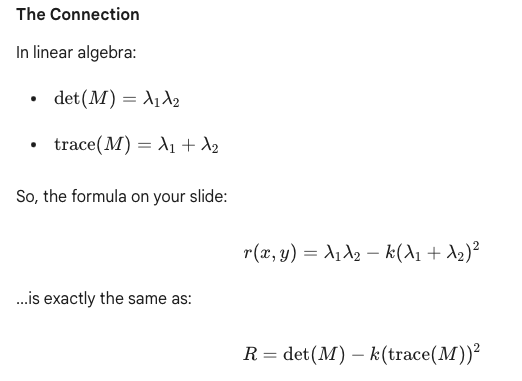

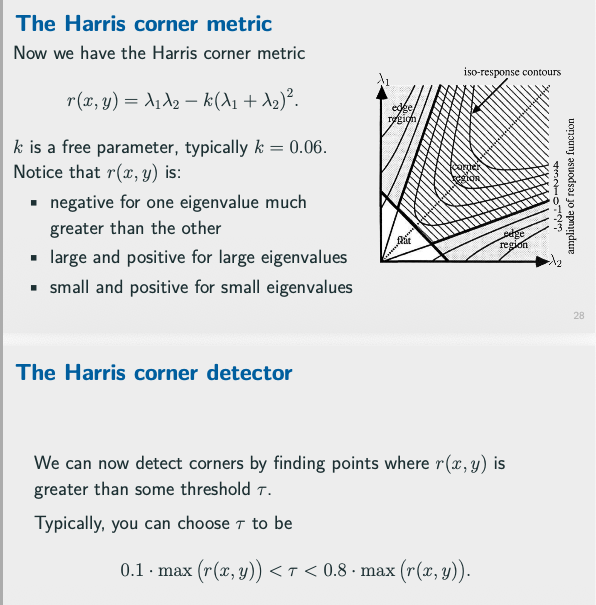